<a href="https://colab.research.google.com/github/Lucaschewitch/Machine-Learning/blob/main/%D0%A1%D0%B0%D0%BC%D0%BE%D0%B9%D0%BB%D0%BE%D0%B2%D0%B0_%D0%92_%D0%90_%D0%9F%D1%80%D0%B0%D0%BA%D1%82%D0%B8%D1%87%D0%B5%D1%81%D0%BA%D0%B0%D1%8F_%D1%80%D0%B0%D0%B1%D0%BE%D1%82%D0%B0_%E2%84%965_%D0%91%D0%B8%D0%B1%D0%BB%D0%B8%D0%BE%D1%82%D0%B5%D0%BA%D0%B0_Pandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическая работа №5. Библиотека Pandas. Визуальный анализ данных

## Комплексное задание №1. Применение основных методов для анализа данных

1. Скачайте этот блокнот к себе.
2. Заполните пропущенные ячейки, отвечая на заданные вопросы. Там должен быть код! (если не сказано обратное)
3. Сохраните результат в своём гитхаб репозитории.

#### Полезная литература
- [**Блокнот с теорией**](https://colab.research.google.com/drive/1SLqmaYz4xEsxVV-LGwb3ityheBTzHJQu?usp=sharing)
- http://pandas.pydata.org/pandas-docs/stable/10min.html
- https://pandas.pydata.org/pandas-docs/stable/indexing.html
- https://pandas.pydata.org/pandas-docs/stable/missing_data.html

В этом задании мы с Вами рассмотрим датасет [Adult Data Set](https://archive.ics.uci.edu/ml/datasets/Adult).
Основывается он на данных переписи населения 1994 года в США.

Расшифровка содержимого колонок:

- age: continuous.
- workclass: Private, Self-emp-not-inc, Self-emp-inc, Federal-gov, Local-gov, State-gov, Without-pay, Never-worked.
- fnlwgt: continuous. sampling weight, more here: SIPP Weighting.
- education: Bachelors, Some-college, 11th, HS-grad, Prof-school, Assoc-acdm, Assoc-voc, 9th, 7th-8th, 12th, Masters, 1st-4th, 10th, Doctorate, 5th-6th, Preschool.
- education-num: continuous.
- marital-status: Married-civ-spouse, Divorced, Never-married, Separated, Widowed, Married-spouse-absent, Married-AF-spouse.
- occupation: Tech-support, Craft-repair, Other-service, Sales, Exec-managerial, Prof-specialty, Handlers-cleaners, Machine-op-inspct, Adm-clerical, Farming-fishing, Transport-moving, Priv-house-serv, Protective-serv, Armed-Forces.
- relationship: Wife, Own-child, Husband, Not-in-family, Other-relative, Unmarried.
- race: White, Asian-Pac-Islander, Amer-Indian-Eskimo, Other, Black.
- sex: Female, Male.
- capital-gain: continuous. Income from investment sources, apart from wages/salary.
- capital-loss: continuous. Losses from investment sources, apart from wages/salary.
- hours-per-week: continuous.
- native-country: United-States, Cambodia, England, Puerto-Rico, Canada, Germany, Outlying-US(Guam-USVI-etc), India, Japan, Greece, South, China, Cuba, Iran, Honduras, Philippines, Italy, Poland, Jamaica, Vietnam, Mexico, Portugal, Ireland, France, Dominican-Republic, Laos, Ecuador, Taiwan, Haiti, Columbia, Hungary, Guatemala, Nicaragua, Scotland, Thailand, Yugoslavia, El-Salvador, Trinadad&Tobago, Peru, Hong, Holand-Netherlands.

In [24]:
%matplotlib inline
import pandas as pd
pd.__version__

'2.2.2'

Если вы увидели warning, не переживайте, всё хорошо.
- https://stackoverflow.com/questions/40845304/runtimewarning-numpy-dtype-size-changed-may-indicate-binary-incompatibility
- https://github.com/numpy/numpy/pull/432

In [25]:
columns='age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income'.split(',')
# df = pd.read_csv('../../data/adult.csv.gz', na_values='?') # можно загрузить из файла или URL
df = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data', na_values=' ?', names=columns)
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


1) Выведите последние 10 элеметнов датасета

In [26]:
print(df.tail(10))

       age      workclass  fnlwgt      education  education.num  \
32551   32        Private   34066           10th              6   
32552   43        Private   84661      Assoc-voc             11   
32553   32        Private  116138        Masters             14   
32554   53        Private  321865        Masters             14   
32555   22        Private  310152   Some-college             10   
32556   27        Private  257302     Assoc-acdm             12   
32557   40        Private  154374        HS-grad              9   
32558   58        Private  151910        HS-grad              9   
32559   22        Private  201490        HS-grad              9   
32560   52   Self-emp-inc  287927        HS-grad              9   

            marital.status          occupation    relationship  \
32551   Married-civ-spouse   Handlers-cleaners         Husband   
32552   Married-civ-spouse               Sales         Husband   
32553        Never-married        Tech-support   Not-in-family  

2) Сколько колонок и сколько строк в этом датасете?

In [27]:
print(df.shape)

(32561, 15)


3) Какие типы данных у элементов этого датасета?

In [28]:
print(df.dtypes)

age                int64
workclass         object
fnlwgt             int64
education         object
education.num      int64
marital.status    object
occupation        object
relationship      object
race              object
sex               object
capital.gain       int64
capital.loss       int64
hours.per.week     int64
native.country    object
income            object
dtype: object


4) Какие признаки имеют пропуски?

In [29]:
print(df.isnull().sum())

age                  0
workclass         1836
fnlwgt               0
education            0
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64


5) Как вы думаете, с чем связаны пропуски этих значение. Напишите развернутый ответ в ячейке ниже.

Ваш ответ: пропуски в данных переписи населения 1994 года могут быть из-за:
1) Отказа от ответа или незнания респондентов.
2) Ошибок при сборе данных.
3) Неприменимости вопросов к части респондентов (безработных, учащихся и т.д.)
4) Особенности выборки (иммигранты, лица без гражданства и т.д.)

6) Какие и сколько различных рабочих классов workclass представлено в выборке?

In [30]:
print(df['workclass'].value_counts(dropna=False))

workclass
 Private             22696
 Self-emp-not-inc     2541
 Local-gov            2093
NaN                   1836
 State-gov            1298
 Self-emp-inc         1116
 Federal-gov           960
 Without-pay            14
 Never-worked            7
Name: count, dtype: int64


7) Какой средний возраст женщин и мужчин?

In [31]:
print(df.groupby('sex')['age'].mean())

sex
Female    36.858230
Male      39.433547
Name: age, dtype: float64


8) Постройте гистограмму(bar) распределения образования людей (education)

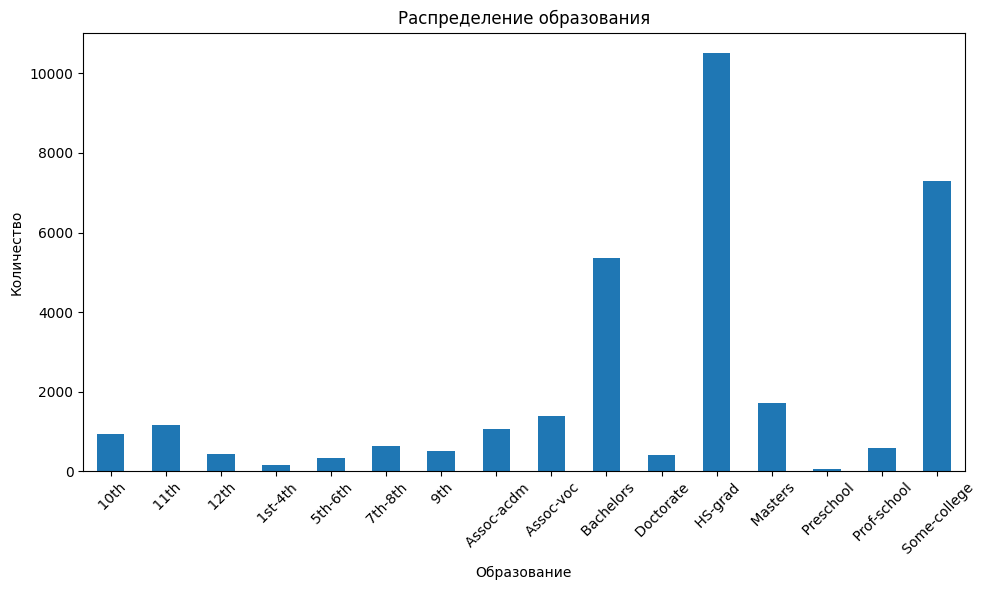

In [32]:
import matplotlib.pyplot as plt

n = df['education'].value_counts().sort_index()
plt.figure(figsize=(10,6))
n.plot(kind='bar')
plt.title('Распределение образования')
plt.xlabel('Образование')
plt.ylabel('Количество')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

9) Каковы средние значения и среднеквадратичные отклонения возраста тех, кто получает более 50K в год (признак income) и тех, кто получает менее 50K в год?

In [33]:
print(df.groupby('income')['age'].agg(['mean', 'std']))

             mean        std
income                      
<=50K   36.783738  14.020088
>50K    44.249841  10.519028


10) Правда ли, что люди, которые получают больше 50k, имеют как минимум высшее образование? (признак education - Bachelors, Prof-school, Assoc-acdm, Assoc-voc, Masters или Doctorate)

In [34]:
vo = ['Bachelors', 'Prof-school', 'Assoc-acdm', 'Assoc-voc', 'Masters', 'Doctorate']
vz = df[df['income'] == '>50K']
nvo = vz[~vz['education'].isin(vo)]

if len(nvo) == 0:
    print("Yes")
else:
    print("No? there is", len(nvo), "without vyshee obrazovanie.")
    print("Examples:", nvo[['education', 'income']].head())

Yes


11) Среди кого больше доля зарабатывающих много (>50K): среди женатых или холостых мужчин (признак marital-status)? Женатыми считаем тех, у кого marital-status начинается с Married (Married-civ-spouse, Married-spouse-absent или Married-AF-spouse), остальных считаем холостыми.

In [39]:
for col in df.select_dtypes(include=['object']).columns:
    df[col] = df[col].str.strip()

m = df[df['sex'] == 'Male'].copy()

m['mg'] = np.where(m['marital.status'].str.startswith('Married', na=False), 'Married', 'Not married')

r = m.groupby('mg')['income'].apply(lambda x: (x == '>50K').mean())
print(">50K:\n", r)

if 'Married' in r.index and 'Not married' in r.index:
    if r['Married'] > r['Not married']:
        print("\nZhenatye zar bolshe.")
    else:
        print("\nHolostye zar bolshe.")
else:
    print("\nIDK")

>50K:
 mg
Married        0.440514
Not married    0.084495
Name: income, dtype: float64

Zhenatye zar bolshe.


12) Постройте [сводную таблицу](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.pivot_table.html) для отображения зависимостей среднего времени работы (hours.per.week) с доходом (income) для каждой страны (native.country).  


> Пример фрагмента таблицы:



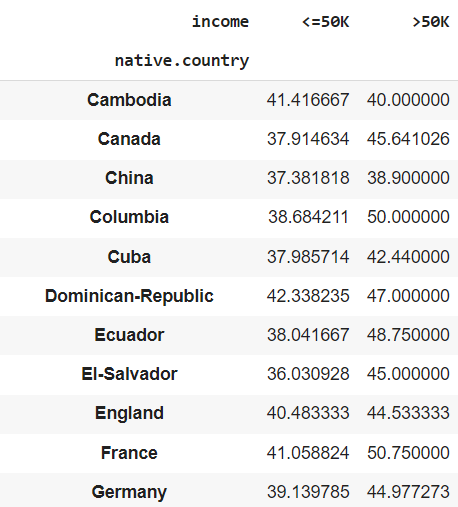

In [40]:
pivo = df.pivot_table(values='hours.per.week', index='native.country', columns='income', aggfunc='mean')
print(pivo.round(2))

income                      <=50K   >50K
native.country                          
Cambodia                    41.42  40.00
Canada                      37.91  45.64
China                       37.38  38.90
Columbia                    38.68  50.00
Cuba                        37.99  42.44
Dominican-Republic          42.34  47.00
Ecuador                     38.04  48.75
El-Salvador                 36.03  45.00
England                     40.48  44.53
France                      41.06  50.75
Germany                     39.14  44.98
Greece                      41.81  50.62
Guatemala                   39.36  36.67
Haiti                       36.33  42.75
Holand-Netherlands          40.00    NaN
Honduras                    34.33  60.00
Hong                        39.14  45.00
Hungary                     31.30  50.00
India                       38.23  46.48
Iran                        41.44  47.50
Ireland                     40.95  48.00
Italy                       39.62  45.40
Jamaica         

13) Постройте сводную таблицу для сравнения уровня образования и разности между capital.gain и capital.loss по следующему алгоритму:&nbsp;  
1. Создайте вспомогательную таблицу (датафрейм) и добавьте в неё столбец "education" из целевой таблицы
2. Добавьте во вспомогательную таблицу ещё один столбец "capital.diff", значиниями которого будут являться разности столбцов capital.gain и capital.loss целевой таблицы
3. Удалите во вспомогательной таблице все строки, в которых значение столбца "capital.diff" равно нулю  
&nbsp; Подсказка:
```
summary_table = summary_table[summary_table['capital.diff'] != 0 ]
```
4. Для набора значений из столбца "capital.diff", необходимо сформировать 10 категорий (кластеров), это можно сделать с помощью математических функций, типа log, извлечение корня N-ой степени и округления, для последующего перехода к категориальным признакам.  
  * В нашем случае, можно воспользоваться методом [pd.qcut()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.qcut.html) и равномерно разделить наш набор данных на целевое количество категорий
5. Добавьте во вспомогательную таблицу столбец "categories", и проинициализируйте его значениями категорий, которые возвращает метод pd.qcut()  
&nbsp; Пример:
```
summary_table['categories'] = pd.qcut(summary_table["capital.diff"], q = 10)

6. Постройте сводную таблицу с помощью метода pivot_table(),

Примерная структура таблицы (в качестве значений выводится количество людей, относящихся к той или иной группе):

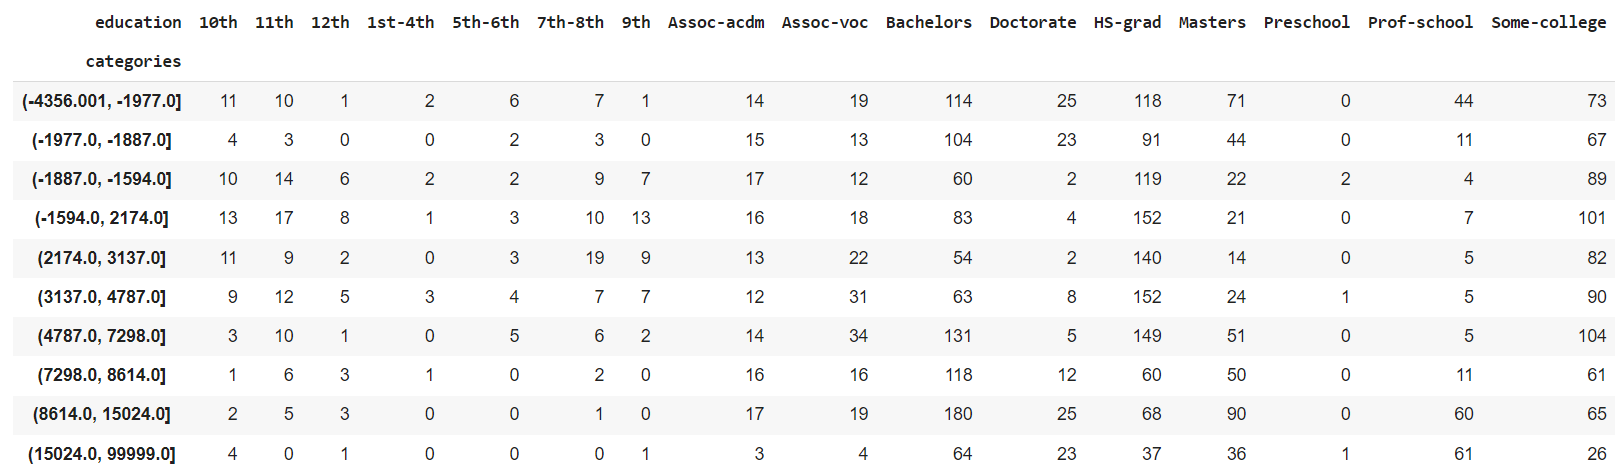

In [42]:
s = df[['education']].copy()

s['capital.diff'] = df['capital.gain'] - df['capital.loss']
s = s[s['capital.diff'] != 0]

s['categories'] = pd.qcut(s['capital.diff'], q=10, duplicates='drop')

t = pd.pivot_table(s, values='capital.diff', index='categories', columns='education', aggfunc='count', fill_value=0)

print(t)

education             10th  11th  12th  1st-4th  5th-6th  7th-8th  9th  \
categories                                                               
(-4356.001, -1977.0]    11    10     1        2        6        7    1   
(-1977.0, -1887.0]       4     3     0        0        2        3    0   
(-1887.0, -1594.0]      10    14     6        2        2        9    7   
(-1594.0, 2174.0]       13    17     8        1        3       10   13   
(2174.0, 3137.0]        11     9     2        0        3       19    9   
(3137.0, 4787.0]         9    12     5        3        4        7    7   
(4787.0, 7298.0]         3    10     1        0        5        6    2   
(7298.0, 8614.0]         1     6     3        1        0        2    0   
(8614.0, 15024.0]        2     5     3        0        0        1    0   
(15024.0, 99999.0]       4     0     1        0        0        0    1   

education             Assoc-acdm  Assoc-voc  Bachelors  Doctorate  HS-grad  \
categories                       

/tmp/ipython-input-364/201950977.py:8: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  t = pd.pivot_table(s, values='capital.diff', index='categories', columns='education', aggfunc='count', fill_value=0)


14) Женщины из каких стран получают в среднем большую зарплату (>50K) чаще.

In [43]:
w = df[df['sex'] == 'Female'].copy()

cs = w.groupby('native.country')['income'].agg(total='count', high_income=lambda x: (x == '>50K').sum()).reset_index()

cs['fraction_high'] = cs['high_income'] / cs['total']

csgo = cs.sort_values('fraction_high', ascending=False)

print(csgo.head(20))

   native.country  total  high_income  fraction_high
40     Yugoslavia      3            1       0.333333
35         Taiwan     15            4       0.266667
9          France     12            3       0.250000
19           Iran      8            2       0.250000
23          Japan     20            5       0.250000
21          Italy     21            5       0.238095
2           China     21            5       0.238095
1          Canada     39            9       0.230769
11         Greece      5            1       0.200000
33       Scotland      5            1       0.200000
8         England     32            6       0.187500
18          India     11            2       0.181818
31       Portugal     12            2       0.166667
16           Hong      6            1       0.166667
17        Hungary      6            1       0.166667
29    Philippines     73           12       0.164384
15       Honduras      7            1       0.142857
20        Ireland      7            1       0.

15) Создайте случайную колонку - magic_salary, которую нужно будет вычислить следующим образом: если зарплата небольшая (<50K), тогда случайно выберите число из диапазона [0,50]. Если зарплата выше 50K тогда из диапазона [51, 200]. Посчитайте среднюю зарплату в час для групп людей с одни уровнем образования на основе нашей случайной колонки magic_salary

In [44]:
l = df['income'] == '<=50K'
nl = l.sum()
nh = len(df) - nl

ml = np.random.uniform(0, 50, nl)
mh = np.random.uniform(51, 200, nh)

df['magic_salary'] = 0.0
df.loc[l, 'magic_salary'] = ml
df.loc[~l, 'magic_salary'] = mh

print(df.groupby('education')['magic_salary'].mean().sort_values(ascending=False))

education
Doctorate       100.965651
Prof-school      98.392853
Masters          81.544431
Bachelors        66.402006
Assoc-voc        50.496827
Assoc-acdm       49.719100
Some-college     44.428437
HS-grad          40.811029
12th             35.410474
10th             32.282213
5th-6th          31.768531
11th             30.772393
7th-8th          30.404357
9th              29.924530
1st-4th          29.347230
Preschool        24.935204
Name: magic_salary, dtype: float64


## Комплексное задание №2. Визуальный анализ данных. Часть 1

In [51]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline

В этом задании Вам предлагается провести визуальный анализ датасета о прокатах велосипедов https://www.kaggle.com/c/bike-sharing-demand/data. Оригинальная задача предполагает построение модели предсказания количества прокатов в городе в зависимости от погоды.

Для каждого дня проката известны следующие признаки (как они были указаны в источнике данных):
- season: 1 - весна, 2 - лето, 3 - осень, 4 - зима
- yr: 0 - 2011, 1 - 2012
- mnth: от 1 до 12
- holiday: 0 - нет праздника, 1 - есть праздник
- weekday: от 0 до 6
- workingday: 0 - нерабочий день, 1 - рабочий день
- weathersit: оценка благоприятности погоды от 1 (чистый, ясный день) до 4 (ливень, туман)
- temp: температура в Цельсиях
- atemp: температура по ощущениям в Цельсиях
- hum: влажность
- windspeed(mph): скорость ветра в милях в час
- windspeed(ms): скорость ветра в метрах в секунду
- cnt: количество арендованных велосипедов (это целевой признак, его мы будем предсказывать)

Загрузите самостоятельно(!), с помощью pandas файл `bikes_rent.csv.gz` и выведите первые 5 строк. Ознакомьтесь с данными с помощью функций describe и info.

In [53]:
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/00275/Bike-Sharing-Dataset.zip'
import zipfile
import io
import requests
r = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(r.content))
df = pd.read_csv(z.open('day.csv'))

df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 13 columns):
season            731 non-null int64
yr                731 non-null int64
mnth              731 non-null int64
holiday           731 non-null int64
weekday           731 non-null int64
workingday        731 non-null int64
weathersit        731 non-null int64
temp              731 non-null float64
atemp             731 non-null float64
hum               731 non-null float64
windspeed(mph)    731 non-null float64
windspeed(ms)     731 non-null float64
cnt               731 non-null int64
dtypes: float64(5), int64(8)
memory usage: 74.3 KB


Давайте посмотрим на графиках, как целевой признак зависит количество прокатов (cnt) зависит от остальных признаков `df.columns[:-1]`.

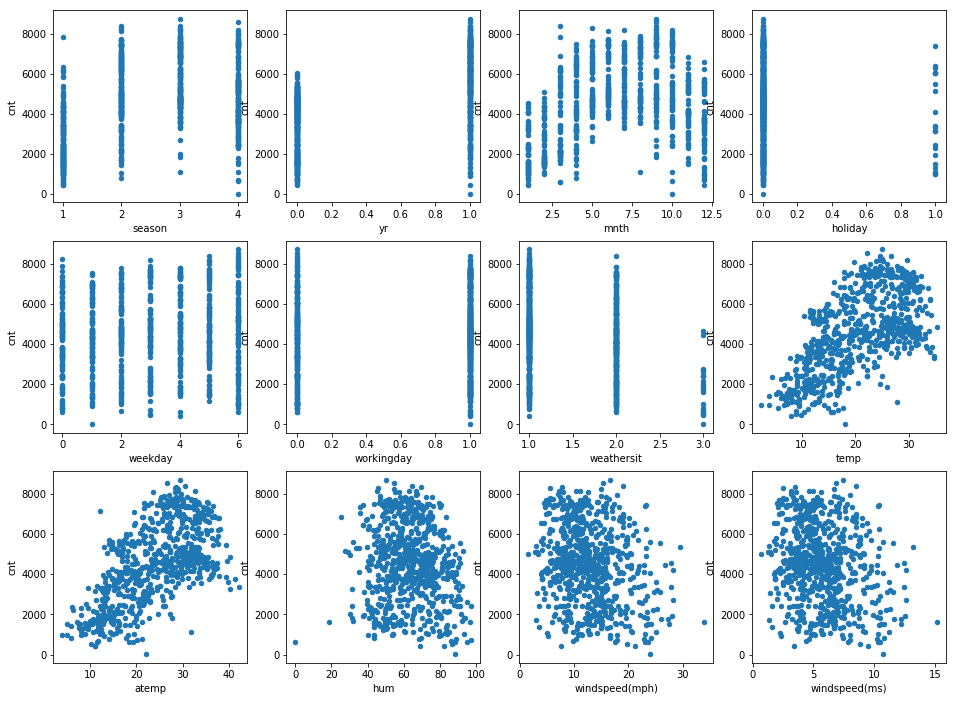

In [ ]:
fig, axes = plt.subplots(nrows=3, ncols=4, figsize=(16, 12))
for idx, feature in enumerate(df.columns[:-1]):
     df.plot(feature, "cnt", subplots=True, kind="scatter", ax=axes[idx // 4, idx % 4])

### 1. Ответьте на вопросы:

#### Каков характер зависимости числа прокатов от месяца?





ответ: зависимость имеет сезонный характер: в тёплые месяцы число прокатов выше, зимой ниже.

#### Укажите один или два признака, от которых число прокатов скорее всего зависит линейно
_(чем больше значение, тем больше прокатов или наоборот, например)_

Можете проверить результат с помощью lnplot.



Ответ: сильная зависимость от температуры и слабая зависимостоь от влажности.

### 2. Корреляционная матрица

Напомним, что корреляция отражает взаимосвязь двух случайных величин. Она бывает положительная и отрицательная. Чем ближе коэффициент корреляции к нулю, тем меньше взаимосвязь. Чем больше абсолютная корреляци, тем взаимосвязь больше.

Постройте heatmap корреляционной матрицы. Матрица формируется средствами pandas, со стандартным значением параметров.



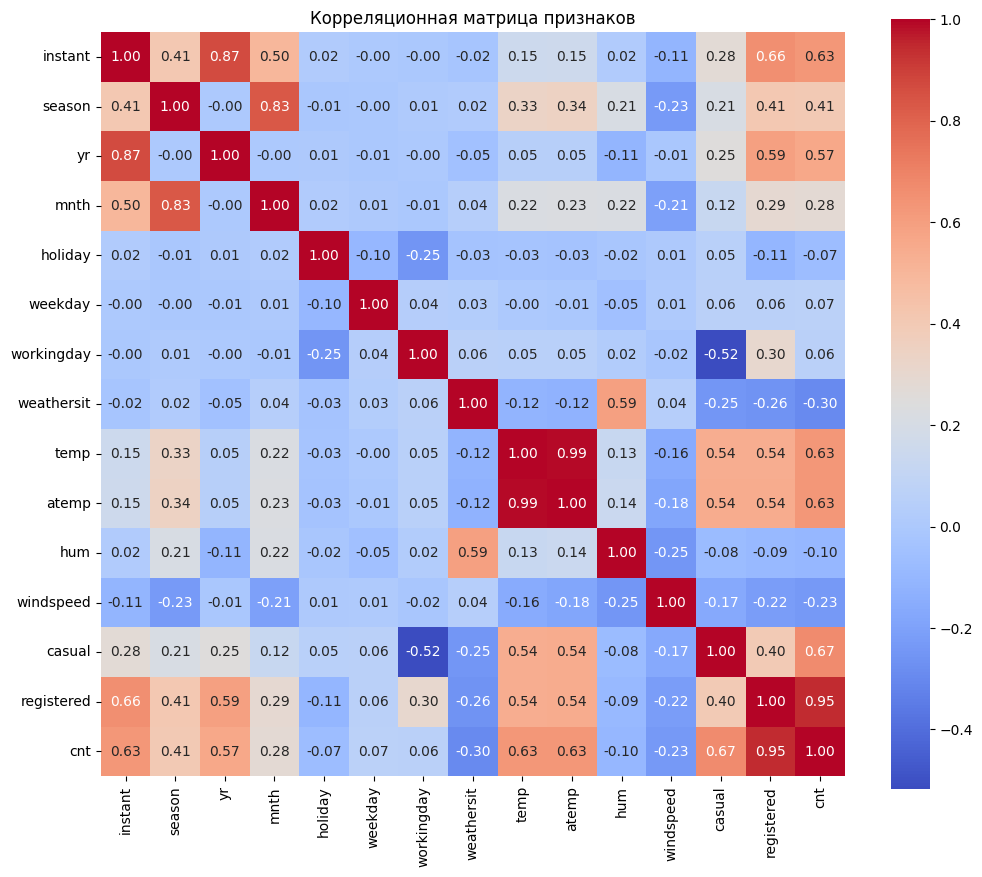

In [54]:
import seaborn as sns


corr_matrix = df.corr(numeric_only=True)  # все столбцы числовые, numeric_only необязателен, но для надёжности

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Корреляционная матрица признаков')
plt.show()


**Ответьте на вопрос**: с какими признаками количество прокатов коррелирует меньше всего (около 4 штуки). А с какими больше всего?

Ответ: Больше всего коррелирует с: temp, atemp, season, yr. Mеньше всего коррелирует с: holiday, weekday, workingday, windspeed(mph)

### 3. Barpot

Постройте Bar-график суммарного количества прокатов велосипедов по месяцам за каждый год одновременно. (будет 24 столбика)



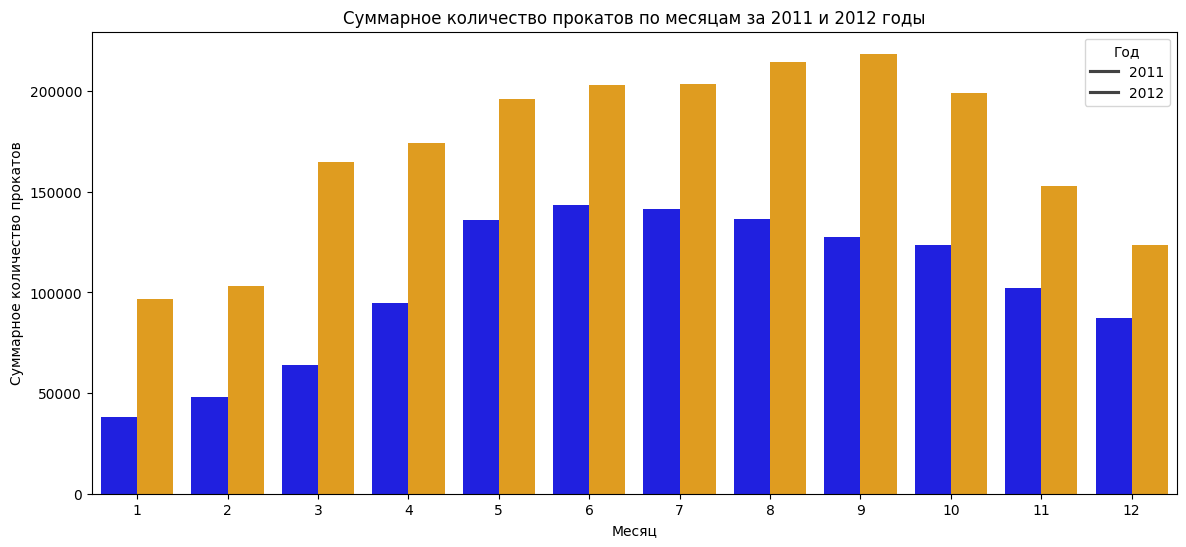

In [58]:
mr = df.groupby(['yr', 'mnth'])['cnt'].sum().reset_index()

mr['year_month'] = mr['yr'].map({0: '2011', 1: '2012'}) + '-' + mr['mnth'].astype(str).str.zfill(2)


plt.figure(figsize=(14, 6))
sns.barplot(data=mr, x='mnth', y='cnt', hue='yr', palette={0: 'blue', 1: 'orange'})
plt.xlabel('Месяц')
plt.ylabel('Суммарное количество прокатов')
plt.title('Суммарное количество прокатов по месяцам за 2011 и 2012 годы')
plt.legend(title='Год', labels=['2011', '2012'])
plt.show()

**Ответьте на вопрос:** почему в предыдущем графике была такая большая корреляция между количеством прокатов и годом?

Ответ: это может быть связано с увеличением популярности сервиса, расширением инфраструктуры, улучшением погодных условий или другими факторами.

### 4. Countplot

Постройте countplot диаграммы для признаков `weekday`, `weathersit`,



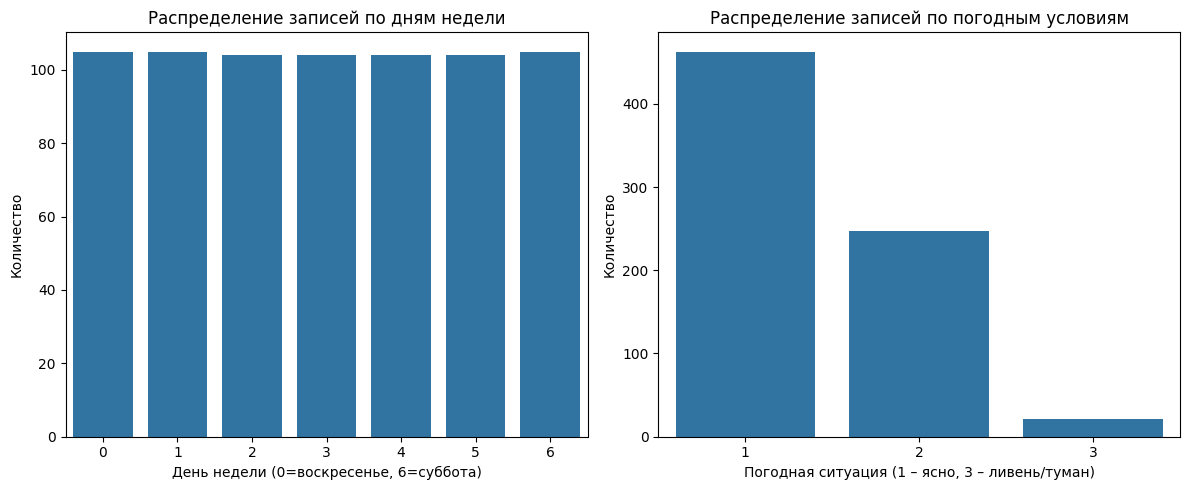

In [60]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(data=df, x='weekday', ax=axes[0])
axes[0].set_title('Распределение записей по дням недели')
axes[0].set_xlabel('День недели (0=воскресенье, 6=суббота)')
axes[0].set_ylabel('Количество')

sns.countplot(data=df, x='weathersit', ax=axes[1])
axes[1].set_title('Распределение записей по погодным условиям')
axes[1].set_xlabel('Погодная ситуация (1 – ясно, 3 – ливень/туман)')
axes[1].set_ylabel('Количество')

plt.tight_layout()
plt.show()

**Ответьте на вопрос:** что вы можете сказать о том, как формировался этот датасет.



Ответ: равномерное распределение количества записей по дням недели (каждый день представлен примерно одинаковое число раз) говорит о том, что данные собирались ежедневно на протяжении всего периода наблюдений без пропусков.

**Ответьте на вопрос:** как называется распределение значений признака `weekday`?

Ответ: равномерное

### 5. Распределение

Постройте распределение целевого признака.



**Ответьте на вопрос:** основываясь на графике, сколько приблизительно в среднем прокатов бывает в день?

Ответ:

### 6. Совместное распределение признаков

Постройте график совместного распределения признаков температура и ощущение температуры.



**Ответьте на вопрос:** вас в этом графике ничего не настораживает? Почему?

Ответ:

### 7. Боксплот (ящик с усами)

Постройте график распределения (боксплот) количества прокатов велосипедов по месяцам в зависимости от того рабочий это день или нет.




**Ответьте на вопрос:** почему в некоторых месяцах чаще берут велосипеды в будний день, а в некоторые - в выходной.

Ответ:

## Комплексное задание №3. Визуальный анализ данных. Часть 2

In [ ]:
!pip install seaborn==0.11.0
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
colab = True # если работаете на своём компьютере, в локальной среде, поставьте False
if colab:
    from google.colab import drive
    drive.mount('/content/drive')

В этом задании Вам предлагается провести визуальный анализ датасета результатов экзаменов студентов  https://www.kaggle.com/spscientist/students-performance-in-exams.

Исходные данные загрузите самостоятельно!

In [ ]:
if colab:
    df = pd.read_csv('/content/drive/My Drive/Data/StudentsPerformance.csv')
else:
    df = pd.read_csv("../../data/StudentsPerformance.csv")

df

### Ход задания:

#### 1. Постройте 3 графика, показывающих распределение результатов экзаменов (каждый график на предмет).


Графики должны быть в одном ряду и у них должен быть общий заголовок "Результаты экзаменов".

Для результатов каждого экзамена посчитайте медианные значения.


#### 2. Образование родителей
Какие уровни образование есть в столбце *'parental level of education'* и сколько строк в датафрейме соответствует каждому уровню?

Постройте график и ответьте на вопрос ниже

Отличаются ли баллы по математике у детей с разным образованием родителей?
Постройте график, где по оси Х находятся уровни образования родителей, а по У - баллы по математике.


#### 3. Выведите число студенток, набравших больше 90 баллов по всем предметам.


#### 4. Сравните баллы у студентов разных полов. Используя agg() выведите минимальное, максимальное и медианное значение


#### 5. Выясните, влияет ли обед и подготовка к тесту на средний балл студентов разного пола
###### (подсказка: используете  [pd.agg()](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.agg.html))

#### 6. Постройте график, показывающий зависимость уровня образования родителей от их расы

#### 7. Постройте график, показывающий зависимость прохождения подготовительного теста от уровня образования родителей.


Кто чаще ходит на курсы: дети, родители которых закончили только старшую школу, или дети, чьи родители получили степень бакалавра\магистра?

#### 8. Постройте plot.pie, показывающий, сколько людей сдали\не сдали экзамен по математике.

Сдавшим считается человек, набравший 40 баллов.

###### Подсказка: создайте столбец в датафрейме, который содержит результат сдачи (сдал или не сдал)

#### 9. Постройте plot.pie, показывающий распределение студентов по оценкам

Оценки студентов выставляются по шкале:<br>
0  - 40 marks : grade E<br>
41 - 60 marks : grade D<br>
60 - 70 marks : grade C<br>
70 - 80 marks : grade B<br>
80 - 90 marks : grade A<br>
90 - 100 marks : grade O<br>

Для этого посчитайте сумму результатов за 3 экзамена и найдите среднее. Оценка выставляется по среднему значению. Если студент не сдал математику(даже если средний балл выше 40), он получает Е

#### 10. Постройте countplot, показывающий зависимость между итоговой оценкой студентов и его полом. Студенты какого пола получили больше оценок О, А, В